# Домашнее задание по ML
## Выполнил: Величко Кирилл Андреевич
## Датасет Electricity (OpenML id=151)

**Цель:** построить модели машинного обучения для предсказания роста или падения цены электроэнергии.

**Задача:** бинарная классификация (UP / DOWN).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

%matplotlib inline

## Шаг 1. Загрузка датасета

In [3]:
data = fetch_openml(data_id=151, as_frame=True)
df = data.frame
df.head()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,UP
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,UP
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,UP
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,UP
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,DOWN


## Шаг 2. EDA (исследование данных)

In [4]:
df.shape

(45312, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45312 entries, 0 to 45311
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   date       45312 non-null  float64 
 1   day        45312 non-null  category
 2   period     45312 non-null  float64 
 3   nswprice   45312 non-null  float64 
 4   nswdemand  45312 non-null  float64 
 5   vicprice   45312 non-null  float64 
 6   vicdemand  45312 non-null  float64 
 7   transfer   45312 non-null  float64 
 8   class      45312 non-null  category
dtypes: category(2), float64(7)
memory usage: 2.5 MB


In [6]:
df.isnull().sum()

,0
date,0
day,0
period,0
nswprice,0
nswdemand,0
vicprice,0
vicdemand,0
transfer,0
class,0


### Распределение классов

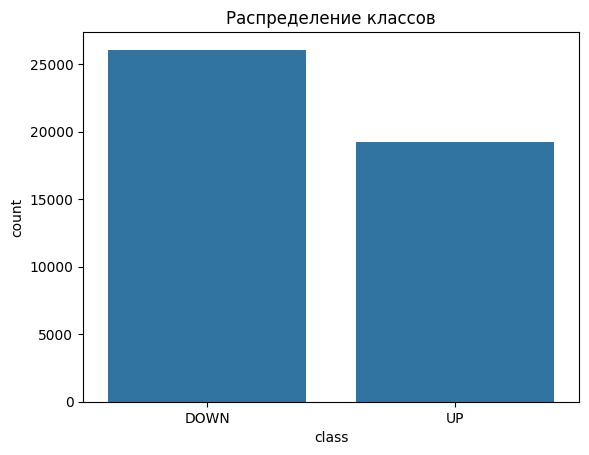

In [7]:
sns.countplot(x='class', data=df)
plt.title('Распределение классов')
plt.show()

### Корреляция признаков

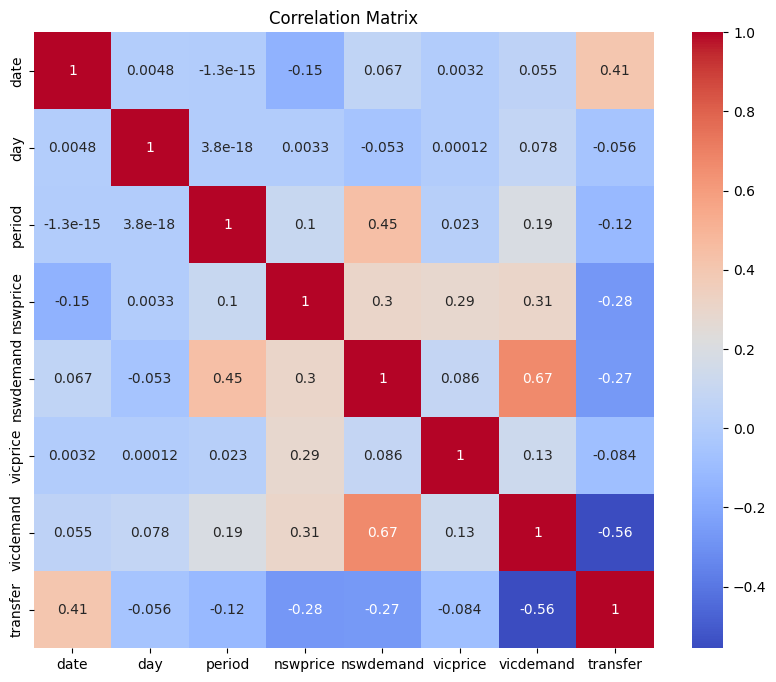

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('class', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Шаг 3. Подготовка данных

In [46]:
X = df.drop(['class'], axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Масштабирование (для Logistic Regression)

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Шаг 4. Обучение моделей

### Logistic Regression

In [48]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

### Decision Tree

In [49]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

### Random Forest

In [50]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Шаг 5. Оценка качества

In [51]:
models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

for name, pred in models.items():
    print(f'===== {name} =====')
    print('Accuracy:', accuracy_score(y_test, pred))
    print('F1-macro:', f1_score(y_test, pred, average="macro"))
    print(classification_report(y_test, pred))
    print()

===== Logistic Regression =====
Accuracy: 0.7567030784508441
F1-macro: 0.7410836232842426
              precision    recall  f1-score   support

        DOWN       0.75      0.87      0.80      5215
          UP       0.77      0.60      0.68      3848

    accuracy                           0.76      9063
   macro avg       0.76      0.74      0.74      9063
weighted avg       0.76      0.76      0.75      9063


===== Decision Tree =====
Accuracy: 0.887233807789915
F1-macro: 0.8845532504172213
              precision    recall  f1-score   support

        DOWN       0.90      0.90      0.90      5215
          UP       0.87      0.87      0.87      3848

    accuracy                           0.89      9063
   macro avg       0.88      0.88      0.88      9063
weighted avg       0.89      0.89      0.89      9063


===== Random Forest =====
Accuracy: 0.908749862076575
F1-macro: 0.9062497947873812
              precision    recall  f1-score   support

        DOWN       0.91      0.93

### Confusion Matrix

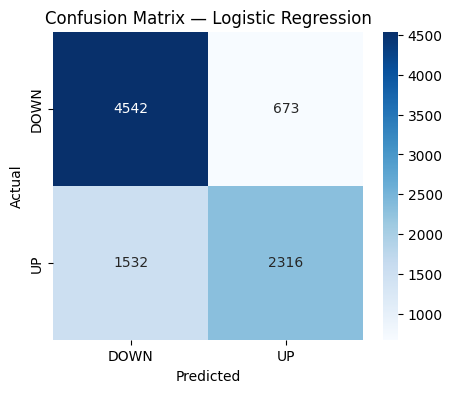

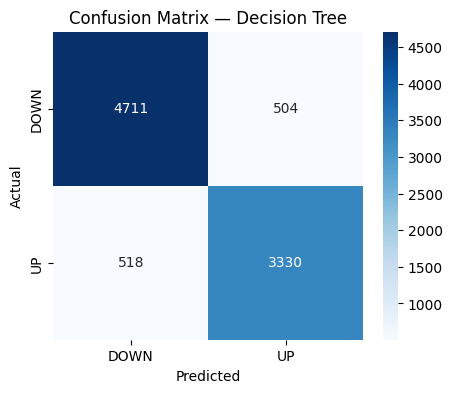

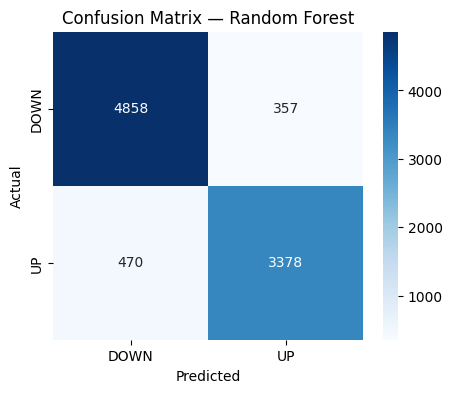

In [52]:
for name, pred in models.items():
    cm = confusion_matrix(y_test, pred, labels=['DOWN','UP'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['DOWN','UP'], yticklabels=['DOWN','UP'], cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [53]:
# выводим веса модели
rf.feature_importances_

array([0.1789915 , 0.05533264, 0.10660985, 0.30734634, 0.1244365 ,
       0.1120519 , 0.06111589, 0.05411537])

## Шаг 6. Эксперименты

In [54]:
dt_depth = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_depth.fit(X_train, y_train)
pred_dt_depth = dt_depth.predict(X_test)
print('Decision Tree max_depth=5 F1:', f1_score(y_test, pred_dt_depth, average='macro'))

Decision Tree max_depth=5 F1: 0.7437561581186638


In [55]:
# vicdemand сильно коррелирует с nswdemand
#
# при обучении на date мы обучаем модель с учетом скрытых трендов, характерных для данного промежутка времени -
# на другом промежутке времени результативность модели может сильно ухудшиться. Кроме того, у date довольно высокий вес
X = df.drop(['class', 'date', 'vicdemand'], axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf.feature_importances_

array([0.06598603, 0.1339635 , 0.3711085 , 0.19135735, 0.1417497 ,
       0.09583492])

In [56]:
models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

for name, pred in models.items():
    print(f'===== {name} =====')
    print('Accuracy:', accuracy_score(y_test, pred))
    print('F1-macro:', f1_score(y_test, pred, average="macro"))
    print(classification_report(y_test, pred))
    print()

===== Logistic Regression =====
Accuracy: 0.7599029019088602
F1-macro: 0.7447965436695281
              precision    recall  f1-score   support

        DOWN       0.75      0.87      0.81      5215
          UP       0.78      0.61      0.68      3848

    accuracy                           0.76      9063
   macro avg       0.76      0.74      0.74      9063
weighted avg       0.76      0.76      0.75      9063


===== Decision Tree =====
Accuracy: 0.7924528301886793
F1-macro: 0.7879686090363851
              precision    recall  f1-score   support

        DOWN       0.82      0.81      0.82      5215
          UP       0.75      0.76      0.76      3848

    accuracy                           0.79      9063
   macro avg       0.79      0.79      0.79      9063
weighted avg       0.79      0.79      0.79      9063


===== Random Forest =====
Accuracy: 0.8496082974732428
F1-macro: 0.8449677391298837
              precision    recall  f1-score   support

        DOWN       0.86      0.

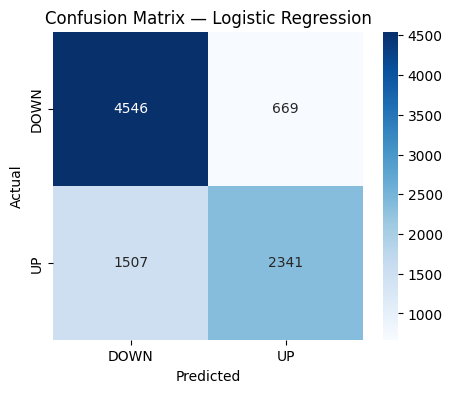

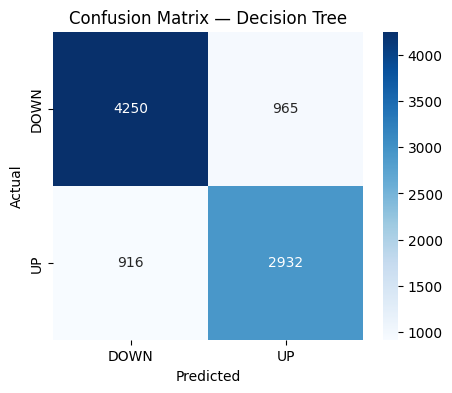

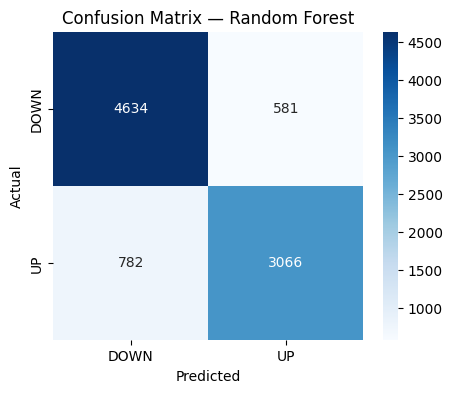

In [57]:
for name, pred in models.items():
    cm = confusion_matrix(y_test, pred, labels=['DOWN','UP'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['DOWN','UP'], yticklabels=['DOWN','UP'], cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Удаление даты уменьшило точность прогнозирования модели. На мой взгляд, для полноценной валидации нужно взять информацию за другой промежуток времени, не поставляемых в рамках учебных данных

## Итоговые выводы

- Лучшая модель: Random Forest
- Наиболее важные признаки: NSWprice, NSWdemand, VICprice. Без удаления даты одним из ключевых признаков является дата, что явно некорректно
- Logistic Regression показала стабильный результат - удаление даты сильно изменило метрики на остальных моделях
- Decision Tree склонна к переобучению